In [1]:
# # Auxiliares ao desenvolvimento, remover uma vez que o código está funcional
%load_ext autoreload
%autoreload 2 
%reload_ext autoreload

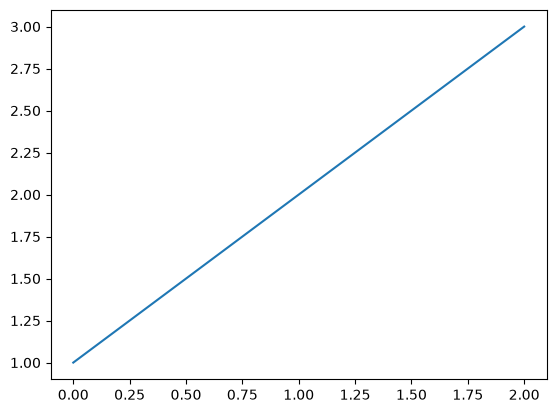

In [2]:
import numpy as np
import matplotlib.pyplot as plt

a = np.array([1,2,3])
plt.plot(a)

In [3]:
from maquina import Maquina
from dados import Dados

dados_maquina = Dados.ler_dados('../dados/dados.txt')

Dados.validar_dados(dados_maquina)

(True, 'Dicionário válido')

In [4]:
dados_maquina_1 = Dados.ler_dados('../dados/dados_1.txt')

dados_maquina_1

Dados.validar_dados(dados_maquina_1)



(False,
 'Variável com nome incorreto ou faltante.',
 "Variáveis esperadas: ['Ua', 'S', 'f', 'Xd', 'Xq', 'Ra', 'P_mec']",
 "Recebidas: ['Ua', 'S', 'f', 'Xd', 'Xq', 'Ra', 'P_bla']")

In [5]:
import plotly.figure_factory as ff
import plotly.graph_objects as go
import numpy as np

# 1. Define Phasor Data (I = 10 A at 30 degrees)
magnitude = 10
angle_deg = 30
angle_rad = np.radians(angle_deg)

# Origin (x, y) and components (u, v)
x_start, y_start = 0, 0
u_end = magnitude * np.cos(angle_rad)
v_end = magnitude * np.sin(angle_rad)

# 2. Create the Quiver Plot
fig = ff.create_quiver(
    x=[x_start], y=[y_start],
    u=[u_end], v=[v_end],
    scale=1.0,           # Set to 1.0 to retain exact vector lengths
    arrow_scale=0.3,     # Adjust arrowhead size
    name="Phasor I"
)

# 3. Enhance with Labels and Formatting
fig.update_layout(
    title="Phasor Diagram",
    xaxis_title="Real Axis",
    yaxis_title="Imaginary Axis",
    xaxis_range=[-2, 12],
    yaxis_range=[-2, 12],
    showlegend=True
)

# Add a marker at the tip for clarity
fig.add_trace(go.Scatter(
    x=[u_end], y=[v_end],
    mode='markers',
    marker=dict(size=8, color='red'),
    name="Phasor Tip"
))

fig.show()


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Define phasor data: A = 3 + 4j, B = 5 - 2j
# Phasor 1: magnitude=5, phase=53.13 deg
# Phasor 2: magnitude=5.38, phase=-21.8 deg
phasors = np.array([3 + 4j, 5 - 2j])

# 2. Extract real (X, U) and imaginary (Y, V) parts
x = np.zeros(len(phasors))
y = np.zeros(len(phasors))
u = np.real(phasors)
v = np.imag(phasors)

# 3. Create the quiver plot
fig, ax = plt.subplots(figsize=(6, 6))

# Plot the vectors with specific formatting for data coordinates
# We set color and label for clarity
q = ax.quiver(
    x,
    y,
    u,
    v,
    angles="xy",
    scale_units="xy",
    scale=1,
    color=["tab:blue", "tab:orange"],
)

# 4. Add custom labels to the vectors
labels = ["Phasor A", "Phasor B"]
for i, (xi, yi, ui, vi) in enumerate(zip(x, y, u, v)):
    # Calculate text position just past the arrow tip for better readability
    ax.text(
        ui * 1.1,
        vi * 1.1,
        labels[i],
        color="black",
        fontsize=12,
        verticalalignment="center",
    )

# 5. Format plot settings
ax.axhline(0, color="black", linewidth=1.5, linestyle="--")
ax.axvline(0, color="black", linewidth=1.5, linestyle="--")
ax.set_xlim(-2, 6)
ax.set_ylim(-4, 6)
ax.set_xlabel("Real Axis")
ax.set_ylabel("Imaginary Axis")
ax.set_title("Phasor Diagram using Matplotlib Quiver")
ax.grid(True, which="both", linestyle=":", alpha=0.7)
ax.set_aspect("equal")  # Critical so the vectors don't look distorted

# Show the plot
plt.show()
